# Test package

In [1]:
%load_ext autoreload
%autoreload 2
import scphytr

In [2]:
import ete3
import pandas as pd
import numpy as np

In [3]:
import ete3

nwk_txt = "(((A:1.,B:1.):1.,(C:1.,D:1.):1.):1., ((E:1.,F:1.):1., (G:1.,H:1.):1.):1.):0.01;" # Tree
tree = scphytr.utils.Tree()
tree.phylotree = ete3.PhyloTree(nwk_txt)
tree.root = tree.phylotree.get_tree_root()
print(tree.phylotree)
print(tree.get_species_cov_matrix())


         /-A
      /-|
     |   \-B
   /-|
  |  |   /-C
  |   \-|
  |      \-D
--|
  |      /-E
  |   /-|
  |  |   \-F
   \-|
     |   /-G
      \-|
         \-H
      A     B     C     D     E     F     G     H
A  3.01  2.01  1.01  1.01  0.01  0.01  0.01  0.01
B  2.01  3.01  1.01  1.01  0.01  0.01  0.01  0.01
C  1.01  1.01  3.01  2.01  0.01  0.01  0.01  0.01
D  1.01  1.01  2.01  3.01  0.01  0.01  0.01  0.01
E  0.01  0.01  0.01  0.01  3.01  2.01  1.01  1.01
F  0.01  0.01  0.01  0.01  2.01  3.01  1.01  1.01
G  0.01  0.01  0.01  0.01  1.01  1.01  3.01  2.01
H  0.01  0.01  0.01  0.01  1.01  1.01  2.01  3.01


In [4]:
bm = scphytr.trait_models.BrownianMotion(tree, trait_means=pd.DataFrame(np.array([10, -10]), index=['0', '1']), 
trait_cov_matrix=np.array([[.1, 0.0], [0.0, 1.]]))

species_trait_values = bm.simulate_traits(seed=3)
species_trait_values

,0,1
A,10.870216,-9.060097
B,10.105672,-8.558392
C,9.633343,-8.453239
D,9.903278,-8.830973
E,9.435335,-5.882458
F,9.771741,-6.707959
G,10.062748,-9.702945
H,10.113382,-9.342799


In [5]:
bm.trait_cov_matrix

array([[0.1, 0. ],
       [0. , 1. ]])

In [6]:
bm.trait_cov_matrix, bm.tree.get_species_cov_matrix()


(array([[0.1, 0. ],
        [0. , 1. ]]),
       A     B     C     D     E     F     G     H
 A  3.01  2.01  1.01  1.01  0.01  0.01  0.01  0.01
 B  2.01  3.01  1.01  1.01  0.01  0.01  0.01  0.01
 C  1.01  1.01  3.01  2.01  0.01  0.01  0.01  0.01
 D  1.01  1.01  2.01  3.01  0.01  0.01  0.01  0.01
 E  0.01  0.01  0.01  0.01  3.01  2.01  1.01  1.01
 F  0.01  0.01  0.01  0.01  2.01  3.01  1.01  1.01
 G  0.01  0.01  0.01  0.01  1.01  1.01  3.01  2.01
 H  0.01  0.01  0.01  0.01  1.01  1.01  2.01  3.01)

In [7]:
tree.set_trait_values(species_trait_values.T.to_dict())

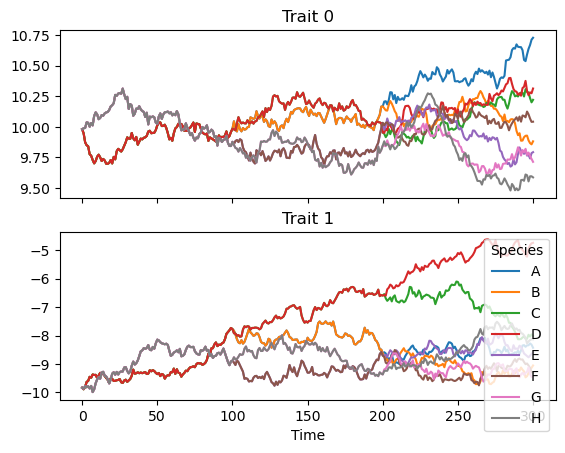

In [8]:
paths = bm.simulate_paths(seed=1)

import matplotlib.pyplot as plt
n_traits = paths['A'].shape[1]
fig, axes = plt.subplots(n_traits, 1, sharex=True)
for i in range(n_traits):
    if n_traits > 1:
        plt.sca(axes[i])
    for species in paths:
        plt.plot(paths[species][:,i], label=f'{species}')
    plt.title(f'Trait {i}')
plt.xlabel('Time')
plt.legend(title='Species')
plt.show()

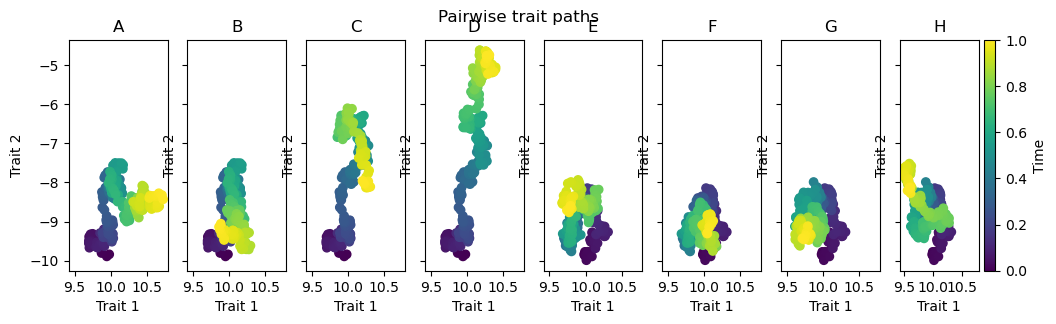

In [9]:
# View pairwise trait paths
fig, axes = plt.subplots(1, len(bm.tree.phylotree.get_leaf_names()), figsize=(12, 3), sharex=True, sharey=True)
for i, species in enumerate(bm.tree.phylotree.get_leaf_names()):
    plt.sca(axes[i])
    plt.scatter(paths[species][:,0], paths[species][:,1], label=species, c=np.linspace(0, 1, len(paths[species][:,0])), cmap='viridis')
    plt.xlabel('Trait 1')
    plt.ylabel('Trait 2')
    plt.title(species)
plt.colorbar(label='Time')
plt.suptitle('Pairwise trait paths')
plt.show()

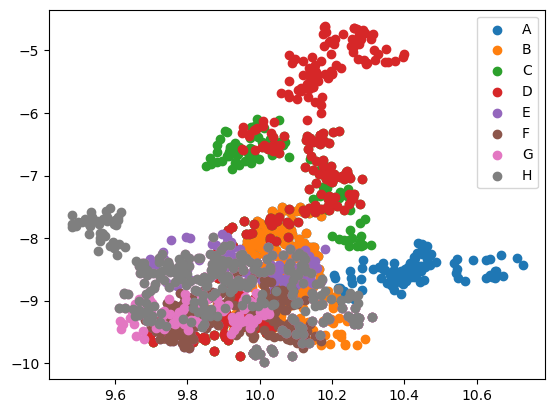

In [10]:
for i, species in enumerate(bm.tree.phylotree.get_leaf_names()):
    plt.scatter(paths[species][:,0], paths[species][:,1], label=species)
plt.legend()
plt.show()

In [11]:
# Store the traits in the leaves
tree.set_trait_values(species_trait_values.T.to_dict())

# Create trait and observation models
trait_model = scphytr.trait_models.BrownianMotion(tree, trait_means=pd.DataFrame(np.array([0., 0.])), trait_cov_matrix=np.array([[1., 0.], [0., 1.]]), learnable_parameters=['rates']) # Learn the evolutionary rates of each trait independently

alg = scphytr.inference.PIC(tree, trait_model)
estimated_rates, root_trait_value, standardized_contrasts = alg.run_pic()
estimated_rates, root_trait_value, standardized_contrasts

(array([0.04048783, 0.21663804]),
 array([ 9.98696456, -8.3173578 ]),
 [array([ 0.38227216, -0.25085248]),
  array([-0.13496759,  0.18886706]),
  array([ 0.23987779, -0.05571284]),
  array([-0.16820294,  0.41275062]),
  array([-0.02531706, -0.18007295]),
  array([-0.16150921,  1.07588801]),
  array([ 0.08066457, -0.23332433])])

In [12]:
# How do we validate the estimated rates?
# If we know the true rates, we can just compare them directly

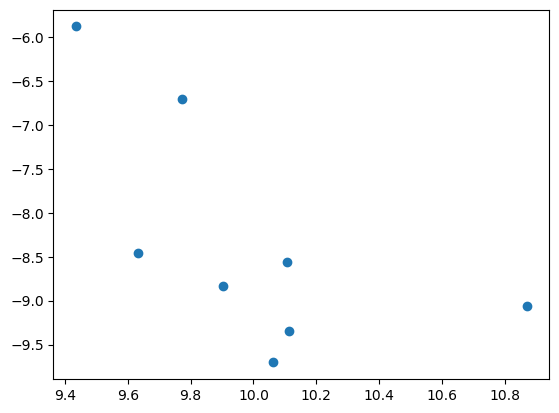

In [13]:
trait_values = np.array(tree.get_trait_values())
plt.scatter(trait_values[:,0], trait_values[:,1])

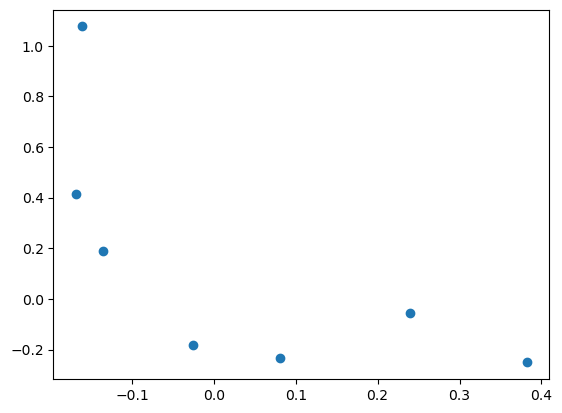

In [14]:
plt.plot(np.array(standardized_contrasts)[:,0], np.array(standardized_contrasts)[:,1], 'o')

In [15]:
estimated_rates

array([0.04048783, 0.21663804])

In [16]:
import jax
jax.config.update("jax_debug_nans", True)

In [17]:
# Create trait and observation models
trait_model = scphytr.trait_models.BrownianMotion(tree, 
    trait_means=pd.DataFrame(np.array([0., 0.])), # initial estimates of trait means
    trait_cov_matrix=pd.DataFrame([[1., 0.], [0., 1.]]), # initial estimates of trait covariance matrix
    learnable_parameters=['rates']) # Learn the evolutionary rates of each trait independently

alg = scphytr.inference.ML(tree, trait_model, lr=0.1)
alg.fit_trait_model(n_steps=1000)

SGD on BrownianMotion: 100%|██████████| 1000/1000 [00:00<00:00, 1867.06it/s, loss=14.5699]


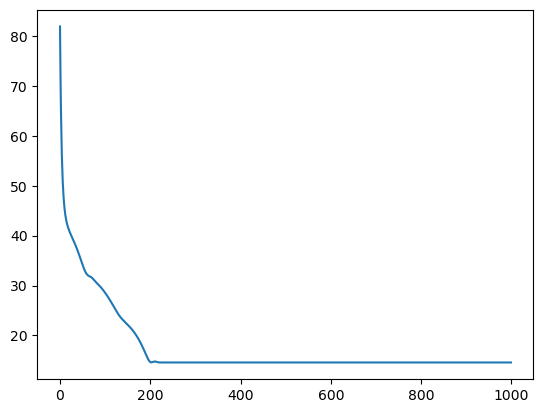

In [18]:
plt.plot(alg.trace)

In [19]:
trait_model.trait_means

0    9.986964
1   -8.317358
dtype: float32

In [20]:
trait_model.trait_cov_matrix

,0,1
0,0.082527,-0.124971
1,-0.124971,0.534404


In [21]:
trait_model.compute_analytical_solution()

(array([[ 9.98696456],
        [-8.3173578 ]]),
 array([[ 0.09431662, -0.14282392],
        [-0.14282392,  0.6107474 ]]))

In [22]:
trait_model.reshape_trait_values(tree.get_trait_values())

array([10.87021639, 10.10567208,  9.63334328,  9.90327846,  9.4353348 ,
        9.77174068, 10.06274831, 10.11338244, -9.06009712, -8.55839216,
       -8.45323906, -8.83097318, -5.88245759, -6.70795883, -9.7029452 ,
       -9.3427993 ])

In [23]:
# Create trait and observation models
trait_model = scphytr.trait_models.BrownianMotion(tree, 
    trait_means=pd.DataFrame(np.array([5., -10.])), # initial estimates of trait means
    trait_cov_matrix=pd.DataFrame([[.1, 0.], [0., 1.]]), # initial estimates of trait covariance matrix
    learnable_parameters=['rates']) # Learn the evolutionary rates of each trait independently

obm = scphytr.observation_models.Gaussian(1.)

alg = scphytr.inference.MCEM(tree, trait_model, observation_model=obm, lr=0.01)
alg.fit_trait_model(n_steps=2000, n_samples=10000)

MCEM on BrownianMotion: 100%|██████████| 2000/2000 [00:15<00:00, 125.30it/s, loss=-8.7903, ESS=3.7490/10000] 


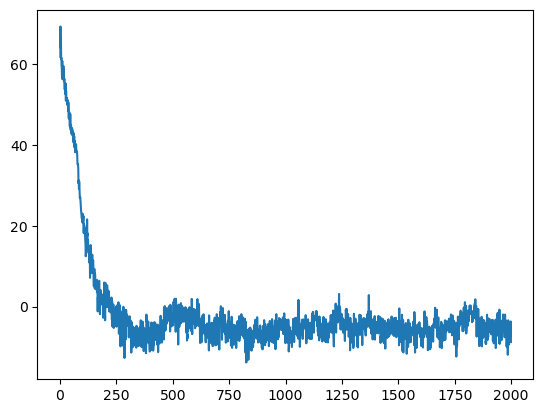

In [24]:
plt.plot(alg.trace)

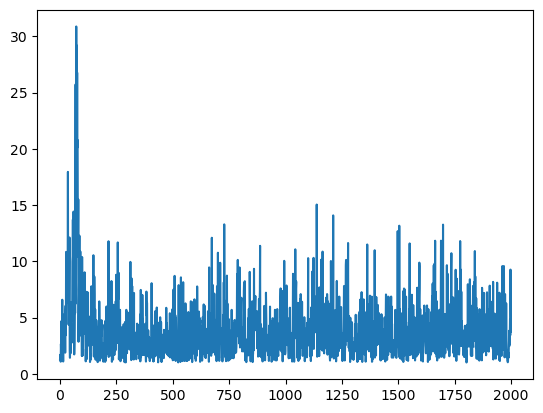

In [25]:
plt.plot(alg.esss)

In [26]:
alg.trait_model.trait_means

0    9.956123
1   -8.345613
dtype: float32

In [27]:
alg.trait_model.trait_cov_matrix

,0,1
0,0.005342,-0.054288
1,-0.054288,0.554880


In [28]:
alg.observation_model.std

Array(0.43243968, dtype=float32)